In [1]:
%matplotlib inline
import numpy as np
import torch, torch.nn as nn
import pandas as pd
import cantera as ct
import matplotlib.pyplot as plt
from scipy.optimize import least_squares


In [2]:
# ── Surrogate paths (point to whichever trained models you have) ─────────
OH_RESULT  = 'result_1192k_oh_train_S_rev.pt'
H2O_RESULT = 'result_1192k_h2o_train_S.pt'
H2O_CSV    = 'hong_1192K_h2o.csv'
OH_CSV     = 'hong_1192K_oh.csv'
YAML_FILE  = 'chem_cti_toy_model_og.yaml'

# ── Observation noise (log-space sigma) ─────────────────────────────────
SIG_LOG     = 0.05
NOISE_FLOOR = 1e-12
LOG_EPS     = 1e-12
INPUT_DIM   = 4
PARAM_NAMES = ['lnA_R1', 'Ea_R1', 'lnA_R2', 'Ea_R2']

# ── Self-test switch (set False to use real experimental data) ───────────
SYNTHETIC = False
X_TRUE    = np.array([0.05, 0.0, -0.05, 0.0])   # only used when SYNTHETIC=True

# ── Reaction indices ─────────────────────────────────────────────────────
IDX_R1 = 21   # H2O2(+M) <-> OH+OH(+M)  falloff
IDX_R2 = 25   # H2O2+OH  <-> HO2+H2O    Arrhenius

# ── Shock-tube condition ─────────────────────────────────────────────────
T_INITIAL = 1192
P_INITIAL = 1.95 * ct.one_atm
INITIAL_X = {'H2O2': 2216e-6, 'H2O': 1364e-6, 'O2': 682e-6,
             'AR': 1.0 - (2216 + 1364 + 682) * 1e-6}

# Shared Cantera grid for both H2O and OH: 1 us steps, 0 .. 1 ms
DT_SIM  = 1e-6
N_STEPS = 1000
T_SIM   = np.linspace(DT_SIM, DT_SIM * N_STEPS, N_STEPS)   # 1 us .. 1 ms


In [3]:
class SurrogateNN(nn.Module):
    def __init__(self, hidden, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden), nn.ReLU(), nn.Linear(hidden, n_out))
    def forward(self, x): return self.net(x)


def load_surrogate(path):
    """Load a ReLU surrogate.  Reads hidden_dim, n_targets, target_times, ln_f, sigma_e."""
    ck     = torch.load(path, weights_only=False)
    tt     = np.asarray(ck["target_times"])
    n_out  = int(ck.get("n_targets", ck["model_state"]["net.2.weight"].shape[0]))
    hidden = int(ck.get("hidden_dim", ck["model_state"]["net.0.weight"].shape[0]))
    ln_f   = float(ck.get("ln_f",    3.0))   # default 3 matches training scripts
    sig_e  = float(ck.get("sigma_e", 5000.0))
    labels = ck.get("target_labels", [f"target_{i}" for i in range(n_out)])
    net = SurrogateNN(hidden=hidden, n_out=n_out)
    net.load_state_dict(ck["model_state"])
    net.eval()
    return net, tt, labels, ln_f, sig_e


oh_net,  oh_times,  oh_labels,  OH_LNF,  OH_SIGE  = load_surrogate(OH_RESULT)
h2o_net, h2o_times, h2o_labels, H2O_LNF, H2O_SIGE = load_surrogate(H2O_RESULT)

OH_SC  = np.array([OH_LNF,  OH_SIGE,  OH_LNF,  OH_SIGE ])   # 2.3026, 5000, ...
H2O_SC = np.array([H2O_LNF, H2O_SIGE, H2O_LNF, H2O_SIGE])   # 3.0,    5000, ...

def residual(p):
    parts = [
        (predict_log(oh_net,  p / OH_SC ) - logOH_obs ) / SIG_LOG,
        (predict_log(h2o_net, p / H2O_SC) - logH2O_obs) / SIG_LOG,
        p / SIG_PRIOR_PHYS,                     # prior block — see below
    ]
    return np.concatenate(parts)
# bounds: |p/OH_SC| <= 1 AND |p/H2O_SC| <= 1  ->  the tighter of the two per component
# Cantera verification uses p directly: A1 = A0*exp(p[0]), Ea1 = Ea0 + p[1], ...

if OH_LNF != H2O_LNF or OH_SIGE != H2O_SIGE:
    print(f"WARNING: surrogates were trained with different ranges!")
    print(f"  OH  : LN_F={OH_LNF}  SIGMA_E={OH_SIGE}")
    print(f"  H2O : LN_F={H2O_LNF}  SIGMA_E={H2O_SIGE}")
    print(f"  Using OH values for physical reporting.")

LN_F    = OH_LNF
SIGMA_E = OH_SIGE

print(f"OH  surrogate: {len(oh_times)} targets, LN_F={OH_LNF}, SIGMA_E={OH_SIGE}")
print(f"  times (ms): {np.round(oh_times*1e3, 4)}")
print(f"H2O surrogate: {len(h2o_times)} targets, LN_F={H2O_LNF}, SIGMA_E={H2O_SIGE}")
print(f"  times (ms): {np.round(h2o_times*1e3, 4)}")


OH  surrogate: 3 targets, LN_F=2.302585092994046, SIGMA_E=5000.0
  times (ms): [0.01   0.0902 0.3   ]
H2O surrogate: 3 targets, LN_F=2.302585092994046, SIGMA_E=5000.0
  times (ms): [0.015 0.093 0.123]


In [4]:
mol_units = ct.UnitSystem({"length":"cm","mass":"g","time":"s","quantity":"mol",
    "pressure":"dyn / cm^2","energy":"erg","temperature":"K","current":"A",
    "activation-energy":"cal / mol"})

_g = ct.Solution(YAML_FILE)
NOM_A_R1   = _g.reaction(IDX_R1).rate.low_rate.pre_exponential_factor
NOM_B_R1   = _g.reaction(IDX_R1).rate.low_rate.temperature_exponent
NOM_EA_R1  = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R1).rate.low_rate.activation_energy} J/kmol", "cal / mol")
NOM_A_R2   = _g.reaction(IDX_R2).rate.pre_exponential_factor
NOM_B_R2   = _g.reaction(IDX_R2).rate.temperature_exponent
NOM_EA_R2  = mol_units.convert_activation_energy_to(
    f"{_g.reaction(IDX_R2).rate.activation_energy} J/kmol", "cal / mol")
del _g
print(f"R1: A={NOM_A_R1:.3e}  Ea={NOM_EA_R1:.0f} cal/mol")
print(f"R2: A={NOM_A_R2:.3e}  Ea={NOM_EA_R2:.0f} cal/mol")


R1: A=2.490e+21  Ea=48749 cal/mol
R2: A=7.590e+10  Ea=7270 cal/mol


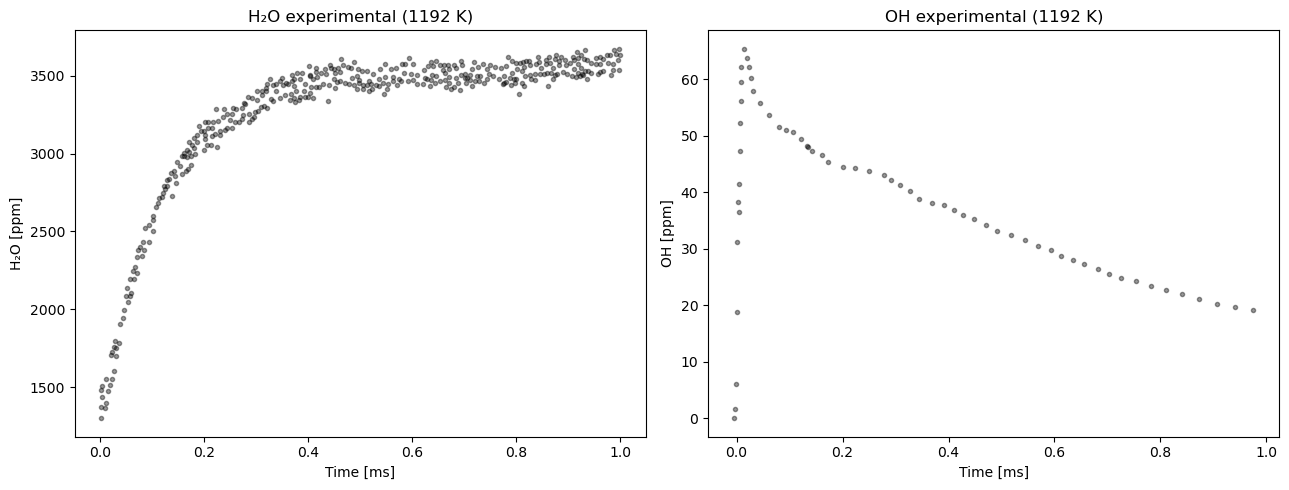

In [5]:
df_h2o = pd.read_csv(H2O_CSV, skipinitialspace=True)
df_oh  = pd.read_csv(OH_CSV,  skipinitialspace=True)

h2o_agg = df_h2o.groupby("Time [ms]")["[H2O] ppm"].mean().reset_index()
t_h2o   = h2o_agg["Time [ms]"].values * 1e-3
y_h2o   = h2o_agg["[H2O] ppm"].values * 1e-6
oh_agg  = df_oh.groupby("Time [ms]")["[OH] ppm"].mean().reset_index()
t_oh    = oh_agg["Time [ms]"].values * 1e-3
y_oh    = oh_agg["[OH] ppm"].values  * 1e-6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "ko", ms=3, alpha=0.4)
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]", title="H₂O experimental (1192 K)")
ax2.plot(df_oh["Time [ms]"],  df_oh["[OH] ppm"],  "ko", ms=3, alpha=0.4)
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]",   title="OH experimental (1192 K)")
plt.tight_layout(); plt.show()


In [6]:
if SYNTHETIC:
    rng = np.random.default_rng(0)
    def _fwd(net, x):
        with torch.no_grad():
            return net(torch.tensor(x, dtype=torch.float32).unsqueeze(0)).numpy().ravel()
    logOH_obs  = _fwd(oh_net,  X_TRUE) + rng.normal(0, SIG_LOG, len(oh_times))
    logH2O_obs = _fwd(h2o_net, X_TRUE) + rng.normal(0, SIG_LOG, len(h2o_times))
    print(f"[synthetic self-test]  X_TRUE = {X_TRUE}")
else:
    y_oh_at_tgt  = np.interp(oh_times,  t_oh,  y_oh)
    y_h2o_at_tgt = np.interp(h2o_times, t_h2o, y_h2o)
    logOH_obs  = np.log(np.clip(y_oh_at_tgt  + LOG_EPS, NOISE_FLOOR, None))
    logH2O_obs = np.log(np.clip(y_h2o_at_tgt + LOG_EPS, NOISE_FLOOR, None))
    print("OH  exp at target times:")
    for lbl, t, v in zip(oh_labels,  oh_times,  y_oh_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")
    print("H2O exp at target times:")
    for lbl, t, v in zip(h2o_labels, h2o_times, y_h2o_at_tgt):
        print(f"  {lbl:<24}  t={t*1e3:.4f} ms   {v*1e6:.2f} ppm")


OH  exp at target times:
  D-opt @ 0.0100 ms         t=0.0100 ms   62.90 ppm
  D-opt @ 0.0902 ms         t=0.0902 ms   51.08 ppm
  D-opt @ 0.3000 ms         t=0.3000 ms   41.76 ppm
H2O exp at target times:
  target_0                  t=0.0150 ms   1482.09 ppm
  target_1                  t=0.0930 ms   2432.76 ppm
  target_2                  t=0.1230 ms   2787.15 ppm


In [7]:
def predict_log(net, x_vec):
    with torch.no_grad():
        return net(torch.tensor(x_vec, dtype=torch.float32).unsqueeze(0)).numpy().ravel()


def net_jacobian(net, x_vec):
    """Analytic Jacobian of one surrogate: shape (n_out, INPUT_DIM)."""
    x_t = torch.tensor(x_vec, dtype=torch.float32, requires_grad=True).unsqueeze(0)
    J = torch.autograd.functional.jacobian(lambda xx: net(xx).squeeze(0), x_t)
    return J.detach().numpy().reshape(-1, INPUT_DIM)


# def residual(x_vec, use_oh=True, use_h2o=True):
#     parts = []
#     if use_oh:  parts.append((predict_log(oh_net,  x_vec) - logOH_obs)  / SIG_LOG)
#     if use_h2o: parts.append((predict_log(h2o_net, x_vec) - logH2O_obs) / SIG_LOG)
#     return np.concatenate(parts)


# def residual_jac(x_vec, use_oh=True, use_h2o=True):
#     parts = []
#     if use_oh:  parts.append(net_jacobian(oh_net,  x_vec) / SIG_LOG)
#     if use_h2o: parts.append(net_jacobian(h2o_net, x_vec) / SIG_LOG)
#     return np.vstack(parts)


# def solve(use_oh, use_h2o, label):
#     sol = least_squares(
#         lambda x: residual(x, use_oh, use_h2o),
#         x0=np.zeros(INPUT_DIM),
#         jac=lambda x: residual_jac(x, use_oh, use_h2o),
#         bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
#         method="trf", verbose=0)
#     cov = np.linalg.inv(sol.jac.T @ sol.jac + np.eye(INPUT_DIM))
#     sig = np.sqrt(np.diag(cov))
#     n_d = (len(oh_times) if use_oh else 0) + (len(h2o_times) if use_h2o else 0)
#     print(f'\n{"="*66}\n  {label}\n{"="*66}')
#     print(f"  cost={0.5*np.sum(sol.fun**2):.4g}  ({n_d} obs pts)")
#     print(f"  {'param':<18}{'x*':>9}{'post_sig_x':>12}{'post_lnf':>11}")
#     for n, xv, sv in zip(PARAM_NAMES, sol.x, sig):
#         print(f"  {n:<18}{xv:>9.4f}{sv:>12.4f}{sv*LN_F:>11.4f}")
#     return sol.x, cov


SIG_PRIOR_X = 0.5    # prior 1σ in normalized x-units. 0.5 if x∈[-1,1] spans ±2σ of your prior;
                     # use 1.0 to exactly reproduce the old "+I" (but now at the correct MAP x*).

def residual(x_vec, use_oh=True, use_h2o=True):
    parts = []
    if use_oh:  parts.append((predict_log(oh_net,  x_vec) - logOH_obs)  / SIG_LOG)
    if use_h2o: parts.append((predict_log(h2o_net, x_vec) - logH2O_obs) / SIG_LOG)
    parts.append(x_vec / SIG_PRIOR_X)                     # ← prior block (mean 0)
    return np.concatenate(parts)

def residual_jac(x_vec, use_oh=True, use_h2o=True):
    parts = []
    if use_oh:  parts.append(net_jacobian(oh_net,  x_vec) / SIG_LOG)
    if use_h2o: parts.append(net_jacobian(h2o_net, x_vec) / SIG_LOG)
    parts.append(np.eye(INPUT_DIM) / SIG_PRIOR_X)         # ← d(x/σ_prior)/dx, matches the block above
    return np.vstack(parts)

def solve(use_oh, use_h2o, label):
    sol = least_squares(lambda x: residual(x, use_oh, use_h2o),
                        x0=np.zeros(INPUT_DIM),
                        jac=lambda x: residual_jac(x, use_oh, use_h2o),
                        bounds=([-1.0]*INPUT_DIM, [1.0]*INPUT_DIM),
                        method="trf", verbose=0)
    J   = residual_jac(sol.x, use_oh, use_h2o)     # includes the prior rows
    cov = np.linalg.inv(J.T @ J)                    # ← NO manual + I anymore
    sig = np.sqrt(np.diag(cov))
    n_d = (len(oh_times) if use_oh else 0) + (len(h2o_times) if use_h2o else 0)
    print(f'\n{"="*66}\n  {label}\n{"="*66}')
    print(f"  cost={0.5*np.sum(sol.fun**2):.4g}  ({n_d} obs pts)")
    print(f"  {'param':<18}{'x*':>9}{'post_sig_x':>12}{'post_lnf':>11}")
    for n, xv, sv in zip(PARAM_NAMES, sol.x, sig):
        print(f"  {n:<18}{xv:>9.4f}{sv:>12.4f}{sv*LN_F:>11.4f}")
    return sol.x, cov

solve(False, True,  "H2O ONLY   (k2 ridge -- flat posterior)")
solve(True,  False, "OH ONLY    (constrains k1/k2 ratio)")
x_opt, Sigma_star = solve(True, True, "JOINT OH+H2O  <-- full constraint")
sig_opt = np.sqrt(np.diag(Sigma_star))



  H2O ONLY   (k2 ridge -- flat posterior)
  cost=0.3345  (3 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1               0.0147      0.3392     0.7811
  Ea_R1               -0.0125      0.3703     0.8527
  lnA_R2              -0.1293      0.4106     0.9455
  Ea_R2                0.1185      0.4260     0.9809

  OH ONLY    (constrains k1/k2 ratio)
  cost=0.4291  (3 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1               0.0186      0.3429     0.7896
  Ea_R1               -0.0214      0.3681     0.8476
  lnA_R2               0.0925      0.3370     0.7759
  Ea_R2               -0.0729      0.3735     0.8600

  JOINT OH+H2O  <-- full constraint
  cost=1.2  (6 obs pts)
  param                    x*  post_sig_x   post_lnf
  lnA_R1              -0.0047      0.3385     0.7795
  Ea_R1               -0.0162      0.3680     0.8473
  lnA_R2               0.0862      0.3366     0.7751
  Ea_R2               -0.0490      0.3698     0.8516


In [8]:
A22_opt  = NOM_A_R1 * np.exp(x_opt[0] * LN_F)
Ea22_opt = NOM_EA_R1 + x_opt[1] * SIGMA_E
A26_opt  = NOM_A_R2 * np.exp(x_opt[2] * LN_F)
Ea26_opt = NOM_EA_R2 + x_opt[3] * SIGMA_E
phys_sc  = np.array([LN_F, SIGMA_E, LN_F, SIGMA_E])
post_phys = sig_opt * phys_sc

print("=" * 70)
print("  Optimized rate parameters at joint MAP estimate")
print("=" * 70)
print(f"  R1 (k1)  A : {NOM_A_R1:.3e} -> {A22_opt:.3e}  "
      f"(x{np.exp(x_opt[0]*LN_F):.3f})  2sig: x{np.exp(2*post_phys[0]):.2f}")
print(f"  R1 (k1) Ea : {NOM_EA_R1:.0f} -> {Ea22_opt:.0f} cal/mol  "
      f"(shift {x_opt[1]*SIGMA_E:+.0f})  2sig: ±{2*post_phys[1]:.0f} cal/mol")
print(f"  R2 (k2)  A : {NOM_A_R2:.3e} -> {A26_opt:.3e}  "
      f"(x{np.exp(x_opt[2]*LN_F):.3f})  2sig: x{np.exp(2*post_phys[2]):.2f}")
print(f"  R2 (k2) Ea : {NOM_EA_R2:.0f} -> {Ea26_opt:.0f} cal/mol  "
      f"(shift {x_opt[3]*SIGMA_E:+.0f})  2sig: ±{2*post_phys[3]:.0f} cal/mol")

if SYNTHETIC:
    print(f"\n  Recovery error |x* - X_TRUE| = {np.abs(x_opt - X_TRUE)}")


  Optimized rate parameters at joint MAP estimate
  R1 (k1)  A : 2.490e+21 -> 2.463e+21  (x0.989)  2sig: x4.75
  R1 (k1) Ea : 48749 -> 48668 cal/mol  (shift -81)  2sig: ±3680 cal/mol
  R2 (k2)  A : 7.590e+10 -> 9.257e+10  (x1.220)  2sig: x4.71
  R2 (k2) Ea : 7270 -> 7025 cal/mol  (shift -245)  2sig: ±3698 cal/mol


In [9]:
def _perturb_gas(x_vec):
    gas = ct.Solution(YAML_FILE)
    A22  = NOM_A_R1 * np.exp(x_vec[0] * LN_F)
    Ea22 = (NOM_EA_R1 + x_vec[1] * SIGMA_E) * 4184.0   # cal/mol -> J/kmol (SI)
    rxn22 = gas.reaction(IDX_R1)
    rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R1, Ea22)
    gas.modify_reaction(IDX_R1, rxn22)
    A26  = NOM_A_R2 * np.exp(x_vec[2] * LN_F)
    Ea26 = (NOM_EA_R2 + x_vec[3] * SIGMA_E) * 4184.0
    rxn26 = gas.reaction(IDX_R2)
    rxn26.rate = ct.Arrhenius(A26, NOM_B_R2, Ea26)
    gas.modify_reaction(IDX_R2, rxn26)
    return gas


def _run_profiles(x_vec):
    """Single Cantera run on T_SIM grid -> H2O and OH profiles, both shape (N_STEPS,)."""
    gas = _perturb_gas(x_vec)
    gas.TPX = T_INITIAL, P_INITIAL, INITIAL_X
    reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
    net     = ct.ReactorNet([reactor])
    h2o_idx = gas.species_index("H2O")
    oh_idx  = gas.species_index("OH")
    h2o_vals = np.empty(N_STEPS)
    oh_vals  = np.empty(N_STEPS)
    for k, t in enumerate(T_SIM):
        net.advance(t)
        h2o_vals[k] = reactor.thermo.X[h2o_idx]
        oh_vals[k]  = reactor.thermo.X[oh_idx]
    return h2o_vals, oh_vals


print("Cantera at x=0 (nominal) ...")
h2o_nom, oh_nom = _run_profiles(np.zeros(INPUT_DIM))
print("Cantera at x* (MAP estimate) ...")
h2o_opt, oh_opt = _run_profiles(x_opt)
print("Done.")


Cantera at x=0 (nominal) ...
Cantera at x* (MAP estimate) ...
Done.


/tmp/ipykernel_313586/2134442639.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R1, Ea22)
/tmp/ipykernel_313586/2134442639.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(A26, NOM_B_R2, Ea26)
/tmp/ipykernel_313586/2134442639.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_313586/2134442639.py:28: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[k] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_313586/2134442639.py:29: Depr

In [10]:
EPS_FD = 1e-3
print(f"Computing FD Cantera Jacobian at x* ({INPUT_DIM} runs) ...")

log_h2o_base = np.log(np.clip(h2o_opt, 1e-30, None))
log_oh_base  = np.log(np.clip(oh_opt,  1e-30, None))
J_h2o = np.zeros((N_STEPS, INPUT_DIM))
J_oh  = np.zeros((N_STEPS, INPUT_DIM))

for k in range(INPUT_DIM):
    dx = np.zeros(INPUT_DIM); dx[k] = EPS_FD
    h2o_p, oh_p = _run_profiles(x_opt + dx)
    J_h2o[:, k] = (np.log(np.clip(h2o_p, 1e-30, None)) - log_h2o_base) / EPS_FD
    J_oh[:, k]  = (np.log(np.clip(oh_p,  1e-30, None)) - log_oh_base)  / EPS_FD
    print(f"  {PARAM_NAMES[k]} done")

from scipy.ndimage import uniform_filter1d
J_oh  = uniform_filter1d(J_oh,  size=20, axis=0)  # smooth time-shift artifact
J_h2o = uniform_filter1d(J_h2o, size=20, axis=0)
h2o_logvar = np.einsum("ti,ij,tj->t", J_h2o, Sigma_star, J_h2o)
oh_logvar  = np.einsum("ti,ij,tj->t", J_oh,  Sigma_star, J_oh)
h2o_upper  = h2o_opt * np.exp(+2 * np.sqrt(h2o_logvar))
h2o_lower  = h2o_opt * np.exp(-2 * np.sqrt(h2o_logvar))
oh_upper   = oh_opt  * np.exp(+2 * np.sqrt(oh_logvar))
oh_lower   = oh_opt  * np.exp(-2 * np.sqrt(oh_logvar))
print("Posterior bands done.")


Computing FD Cantera Jacobian at x* (4 runs) ...
  lnA_R1 done
  Ea_R1 done
  lnA_R2 done
  Ea_R2 done
Posterior bands done.


/tmp/ipykernel_313586/2134442639.py:6: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn22.rate.low_rate = ct.Arrhenius(A22, NOM_B_R1, Ea22)
/tmp/ipykernel_313586/2134442639.py:11: DeprecationWarning: class Arrhenius: To be removed after Cantera 3.2. Replace with 'ArrheniusRate'
  rxn26.rate = ct.Arrhenius(A26, NOM_B_R2, Ea26)
/tmp/ipykernel_313586/2134442639.py:20: DeprecationWarning: ReactorBase.__init__: After Cantera 3.2, the default value of the `clone` argument will be `True`, resulting in an independent copy of the `phase` being created for use by this reactor. Add the `clone=False` argument to retain the old behavior of sharing `Solution` objects.
  reactor = ct.IdealGasConstPressureReactor(gas, energy="on")
/tmp/ipykernel_313586/2134442639.py:28: DeprecationWarning: ReactorBase.thermo: To be removed after Cantera 3.2. Renamed to `phase`.
  h2o_vals[k] = reactor.thermo.X[h2o_idx]
/tmp/ipykernel_313586/2134442639.py:29: Depr

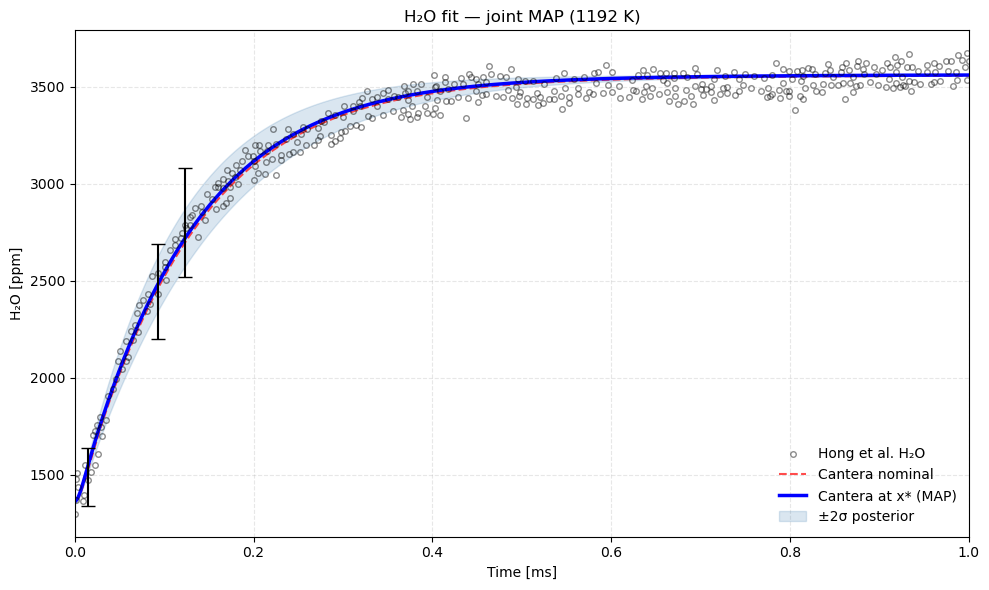

In [11]:
# ── Figure 1: H2O fit ────────────────────────────────────────────────────
if not SYNTHETIC:
    y_exp_h2o_ppm = y_h2o_at_tgt * 1e6
    yerr_up = y_exp_h2o_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_dn = y_exp_h2o_ppm * (1 - np.exp(-2*SIG_LOG))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3,
        label="Hong et al. H₂O")
if not SYNTHETIC:
    ax.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                yerr=[yerr_dn, yerr_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="H₂O [ppm]",
       xlim=[0, 1.0], title="H₂O fit — joint MAP (1192 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


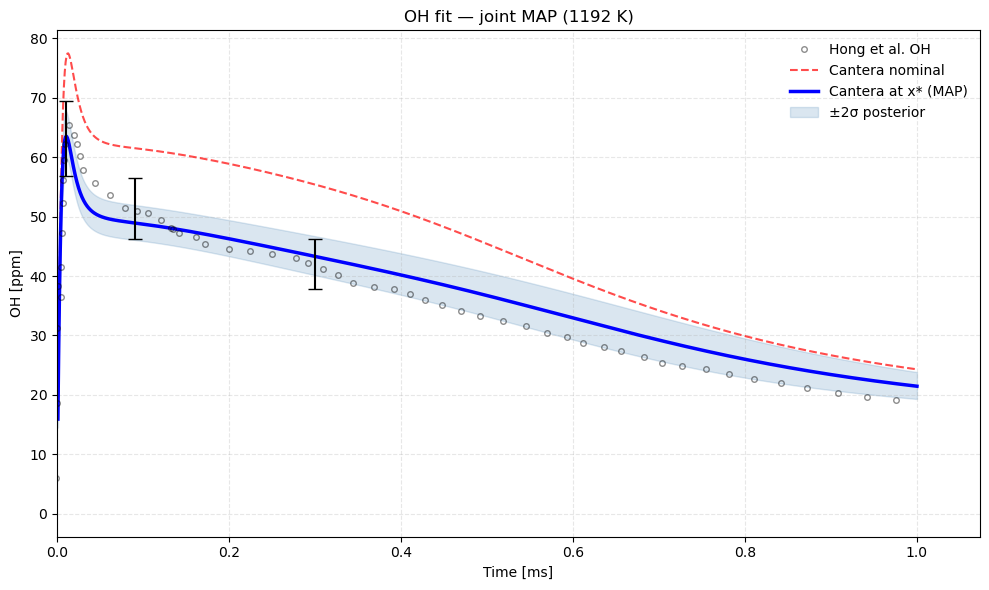

In [12]:
# ── Figure 2: OH fit ─────────────────────────────────────────────────────
if not SYNTHETIC:
    y_exp_oh_ppm = y_oh_at_tgt * 1e6
    yerr_oh_up = y_exp_oh_ppm * (np.exp(+2*SIG_LOG) - 1)
    yerr_oh_dn = y_exp_oh_ppm * (1 - np.exp(-2*SIG_LOG))
oh_xlim = max(t_oh.max()*1e3 * 1.1, 0.06)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
        mfc="none", mec="k", ms=4, alpha=0.45, zorder=3,
        label="Hong et al. OH")
if not SYNTHETIC:
    ax.errorbar(oh_times*1e3, y_exp_oh_ppm,
                yerr=[yerr_oh_dn, yerr_oh_up],
                fmt="none", ecolor="k", elinewidth=1.5, capsize=5, zorder=4)
ax.plot(T_SIM*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Cantera nominal")
ax.plot(T_SIM*1e3, oh_opt*1e6, "b-",  lw=2.5, label="Cantera at x* (MAP)")
ax.fill_between(T_SIM*1e3, oh_lower*1e6, oh_upper*1e6,
                color="steelblue", alpha=0.20, label="±2σ posterior")
ax.set(xlabel="Time [ms]", ylabel="OH [ppm]",
       xlim=[0, oh_xlim], title="OH fit — joint MAP (1192 K)")
ax.legend(frameon=False); ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout(); plt.show()


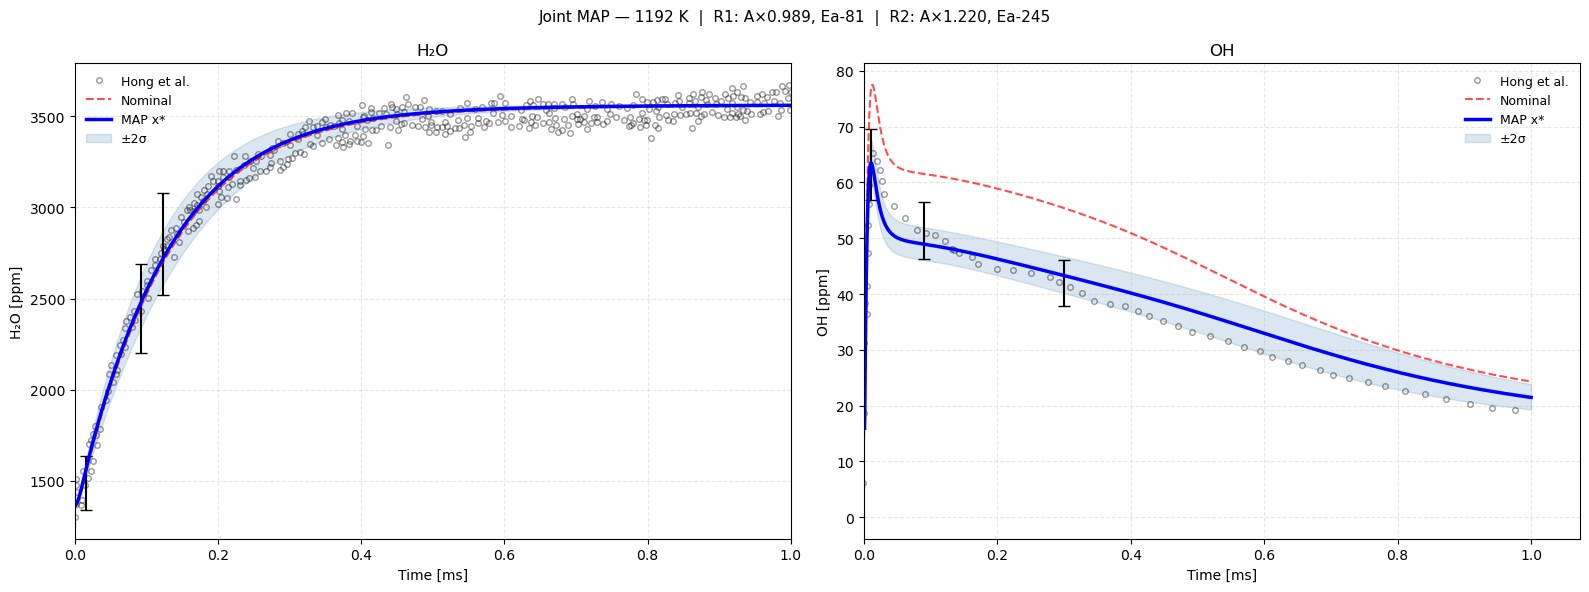

In [13]:
# ── Figure 3: combined H2O + OH ─────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(df_h2o["Time [ms]"], df_h2o["[H2O] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax1.errorbar(h2o_times*1e3, y_exp_h2o_ppm,
                 yerr=[yerr_dn, yerr_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax1.plot(T_SIM*1e3, h2o_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax1.plot(T_SIM*1e3, h2o_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax1.fill_between(T_SIM*1e3, h2o_lower*1e6, h2o_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax1.set(xlabel="Time [ms]", ylabel="H₂O [ppm]",
        xlim=[0, 1.0], title="H₂O")
ax1.legend(frameon=False, fontsize=9); ax1.grid(True, ls="--", alpha=0.3)

ax2.plot(df_oh["Time [ms]"], df_oh["[OH] ppm"], "o",
         mfc="none", mec="k", ms=4, alpha=0.4, label="Hong et al.")
if not SYNTHETIC:
    ax2.errorbar(oh_times*1e3, y_exp_oh_ppm,
                 yerr=[yerr_oh_dn, yerr_oh_up], fmt="none",
                 ecolor="k", elinewidth=1.5, capsize=4)
ax2.plot(T_SIM*1e3, oh_nom*1e6, "r--", lw=1.5, alpha=0.7, label="Nominal")
ax2.plot(T_SIM*1e3, oh_opt*1e6, "b-",  lw=2.5, label="MAP x*")
ax2.fill_between(T_SIM*1e3, oh_lower*1e6, oh_upper*1e6,
                 color="steelblue", alpha=0.20, label="±2σ")
ax2.set(xlabel="Time [ms]", ylabel="OH [ppm]",
        xlim=[0, oh_xlim], title="OH")
ax2.legend(frameon=False, fontsize=9); ax2.grid(True, ls="--", alpha=0.3)

fig.suptitle(
    f"Joint MAP — 1192 K  |  "
    f"R1: A×{np.exp(x_opt[0]*LN_F):.3f}, Ea{x_opt[1]*SIGMA_E:+.0f}  |  "
    f"R2: A×{np.exp(x_opt[2]*LN_F):.3f}, Ea{x_opt[3]*SIGMA_E:+.0f}",
    fontsize=11)
plt.tight_layout(); plt.show()
